<a href="https://colab.research.google.com/github/ajaysn88/Machine_learning_2/blob/main/Lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# -----------------------------------------
# SUPERVISED LEARNING PIPELINE
# -----------------------------------------

import pandas as pd
import matplotlib.pyplot as plt
# Upload file from your computer
from google.colab import files

uploaded = files.upload()


Saving data1.csv to data1.csv


Original Dataset Shape: (569, 33)
Training samples: 455
Testing samples: 114

========== MODEL EVALUATION ==========
Accuracy  : 96.49%
Precision : 97.50%
Recall    : 92.86%
F1 Score  : 95.12%

Confusion Matrix:
[[71  1]
 [ 3 39]]


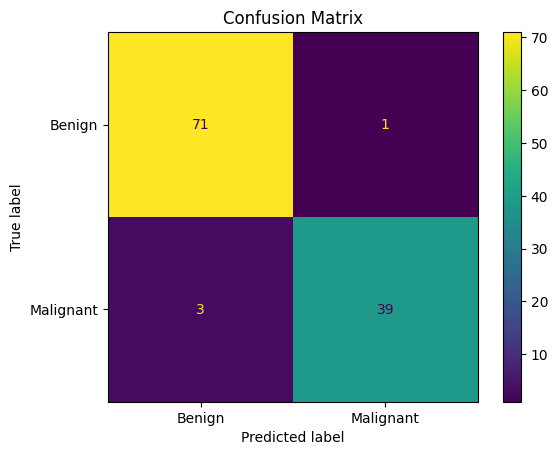


Classification Report:
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# 1. Load dataset
df = pd.read_csv("data1.csv")

print("Original Dataset Shape:", df.shape)

# 2. Remove unnecessary columns
df = df.drop(columns=["id", "Unnamed: 32"], errors="ignore")

# 3. Encode target variable
df["diagnosis"] = df["diagnosis"].map({
    "M": 1,
    "B": 0
})

# 4. Separate features and target
X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

# 5. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

# 6. Feature scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 7. Create classifier
model = LogisticRegression(random_state=42)

# 8. Train model
model.fit(X_train, y_train)

# 9. Predict
y_pred = model.predict(X_test)

# 10. Evaluation
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n========== MODEL EVALUATION ==========")

print(f"Accuracy  : {accuracy * 100:.2f}%")
print(f"Precision : {precision * 100:.2f}%")
print(f"Recall    : {recall * 100:.2f}%")
print(f"F1 Score  : {f1 * 100:.2f}%")

# 11. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# 12. Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign", "Malignant"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

# 13. Classification report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Benign", "Malignant"]
    )
)